In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, precision_recall_curve)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')
import joblib

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [7]:
df = pd.read_csv('creditcard.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())
print("\nDataset Info:")
df.info()
print("\nMissing Values:", df.isnull().sum().sum())
print("\nClass Distribution:")
print(df['Class'].value_counts())
print(f"\nFraud percentage: {df['Class'].mean()*100:.4f}%")

Dataset Shape: (284807, 31)

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21   

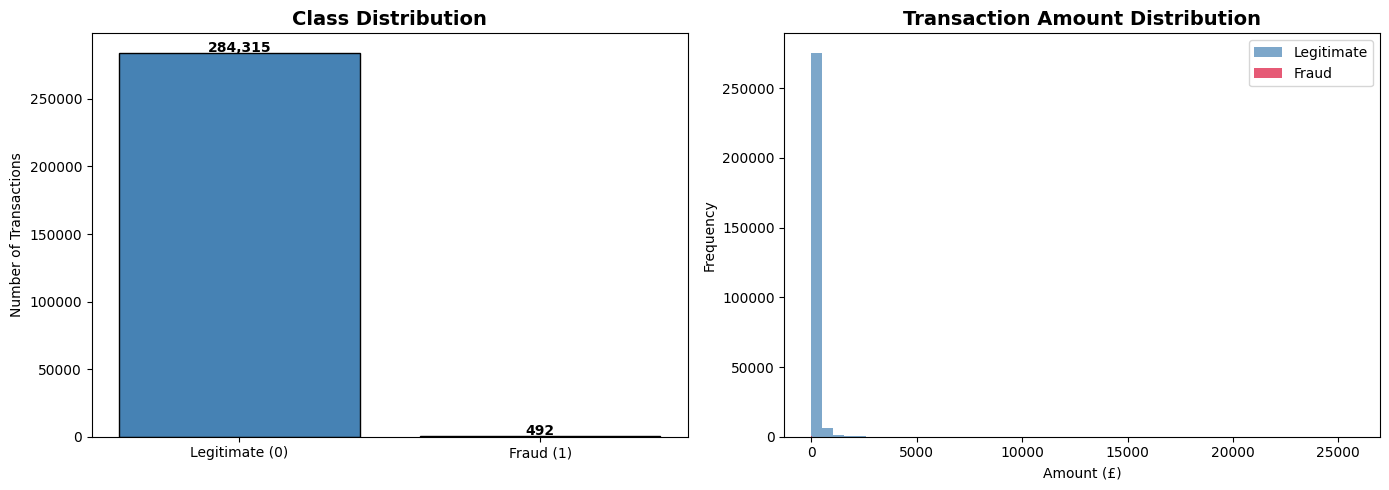

Chart saved!


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution bar chart
class_counts = df['Class'].value_counts()
axes[0].bar(['Legitimate (0)', 'Fraud (1)'], class_counts.values, 
            color=['steelblue', 'crimson'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Transaction amount by class - fixed version
legitimate = df[df['Class'] == 0]['Amount']
fraud = df[df['Class'] == 1]['Amount']

axes[1].hist(legitimate, bins=50, alpha=0.7, color='steelblue', label='Legitimate')
axes[1].hist(fraud, bins=50, alpha=0.7, color='crimson', label='Fraud')
axes[1].set_title('Transaction Amount Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Amount (£)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [9]:
# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Create a new scaler fitted on both Amount and Time together
scaler = StandardScaler()
X[['Amount', 'Time']] = scaler.fit_transform(X[['Amount', 'Time']])

# Save the correctly fitted scaler
joblib.dump(scaler, 'scaler.pkl')

# Train/test split — stratified to preserve fraud ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set:     {X_test.shape[0]:,} samples")
print(f"\nTraining fraud cases: {y_train.sum()} ({y_train.mean()*100:.3f}%)")
print(f"Test fraud cases:     {y_test.sum()} ({y_test.mean()*100:.3f}%)")

Training set: 227,845 samples
Test set:     56,962 samples

Training fraud cases: 394 (0.173%)
Test fraud cases:     98 (0.172%)


In [10]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(f"  Legitimate: {(y_train==0).sum():,} | Fraud: {(y_train==1).sum():,}")
print("\nAfter SMOTE:")
print(f"  Legitimate: {(y_train_smote==0).sum():,} | Fraud: {(y_train_smote==1).sum():,}")

Before SMOTE:
  Legitimate: 227,451 | Fraud: 394

After SMOTE:
  Legitimate: 227,451 | Fraud: 227,451


In [11]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss')
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'roc_auc': roc_auc_score(y_test, y_prob),
        'report': classification_report(y_test, y_pred, 
                                        target_names=['Legitimate', 'Fraud'])
    }
    print(f"  ✓ Done — ROC-AUC: {results[name]['roc_auc']:.4f}\n")

print("All models trained!")

Training Logistic Regression...
  ✓ Done — ROC-AUC: 0.9698

Training Random Forest...
  ✓ Done — ROC-AUC: 0.9731

Training XGBoost...
  ✓ Done — ROC-AUC: 0.9792

All models trained!


In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

#Add Decision Tree to models and train
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_model.fit(X_train_smote, y_train_smote)
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

results['Decision Tree'] = {
    'model': dt_model,
    'y_pred': y_pred_dt,
    'y_prob': y_prob_dt,
    'roc_auc': roc_auc_score(y_test, y_prob_dt),
    'report': classification_report(y_test, y_pred_dt,
                                    target_names=['Legitimate', 'Fraud'])
}

print("Decision Tree Results:")
print(results['Decision Tree']['report'])
print(f"ROC-AUC: {results['Decision Tree']['roc_auc']:.4f}")

#Cross validation on all models
print("\n" + "="*60)
print("5-FOLD CROSS VALIDATION RESULTS")
print("="*60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_models = {
    'Logistic Regression': results['Logistic Regression']['model'],
    'Decision Tree': dt_model,
    'Random Forest': results['Random Forest']['model'],
    'XGBoost': results['XGBoost']['model']
}

cv_results = {}
for name, model in all_models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:<25} Mean AUC: {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

print("="*60)

Decision Tree Results:
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     56864
       Fraud       0.08      0.81      0.15        98

    accuracy                           0.98     56962
   macro avg       0.54      0.90      0.57     56962
weighted avg       1.00      0.98      0.99     56962

ROC-AUC: 0.8951

5-FOLD CROSS VALIDATION RESULTS
Logistic Regression       Mean AUC: 0.9734 (+/- 0.0141)
Decision Tree             Mean AUC: 0.8723 (+/- 0.0306)
Random Forest             Mean AUC: 0.9466 (+/- 0.0220)
XGBoost                   Mean AUC: 0.9446 (+/- 0.0386)


In [13]:
from sklearn.model_selection import GridSearchCV

print("Running hyperparameter tuning on XGBoost...")
print("This may take a few minutes...\n")

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
}

# Grid search with cross validation
xgb_base = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
grid_search = GridSearchCV(
    xgb_base,
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_smote, y_train_smote)

print(f"\nBest Parameters Found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param:<20} {value}")
print(f"\nBest Cross-Val AUC: {grid_search.best_score_:.4f}")

# Evaluate tuned model on test set
tuned_xgb = grid_search.best_estimator_
y_pred_tuned = tuned_xgb.predict(X_test)
y_prob_tuned = tuned_xgb.predict_proba(X_test)[:, 1]
tuned_auc = roc_auc_score(y_test, y_prob_tuned)

print(f"\nTuned XGBoost Test Set Results:")
print(f"{'='*50}")
print(classification_report(y_test, y_pred_tuned,
                             target_names=['Legitimate', 'Fraud']))
print(f"ROC-AUC: {tuned_auc:.4f}")

# Compare default vs tuned
default_auc = results['XGBoost']['roc_auc']
improvement = (tuned_auc - default_auc) * 100
print(f"\nComparison:")
print(f"  Default XGBoost AUC:  {default_auc:.4f}")
print(f"  Tuned XGBoost AUC:    {tuned_auc:.4f}")
print(f"  Improvement:          {improvement:+.4f}")

# Save tuned model
results['XGBoost Tuned'] = {
    'model': tuned_xgb,
    'y_pred': y_pred_tuned,
    'y_prob': y_prob_tuned,
    'roc_auc': tuned_auc,
    'report': classification_report(y_test, y_pred_tuned,
                                    target_names=['Legitimate', 'Fraud'])
}

joblib.dump(tuned_xgb, 'best_model_tuned_xgboost.pkl')
print("\nTuned model saved as best_model_tuned_xgboost.pkl")

Running hyperparameter tuning on XGBoost...
This may take a few minutes...

Fitting 3 folds for each of 36 candidates, totalling 108 fits

Best Parameters Found:
  learning_rate        0.3
  max_depth            7
  n_estimators         200
  subsample            0.8

Best Cross-Val AUC: 1.0000

Tuned XGBoost Test Set Results:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.82      0.87      0.84        98

    accuracy                           1.00     56962
   macro avg       0.91      0.93      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9777

Comparison:
  Default XGBoost AUC:  0.9792
  Tuned XGBoost AUC:    0.9777
  Improvement:          -0.1448

Tuned model saved as best_model_tuned_xgboost.pkl


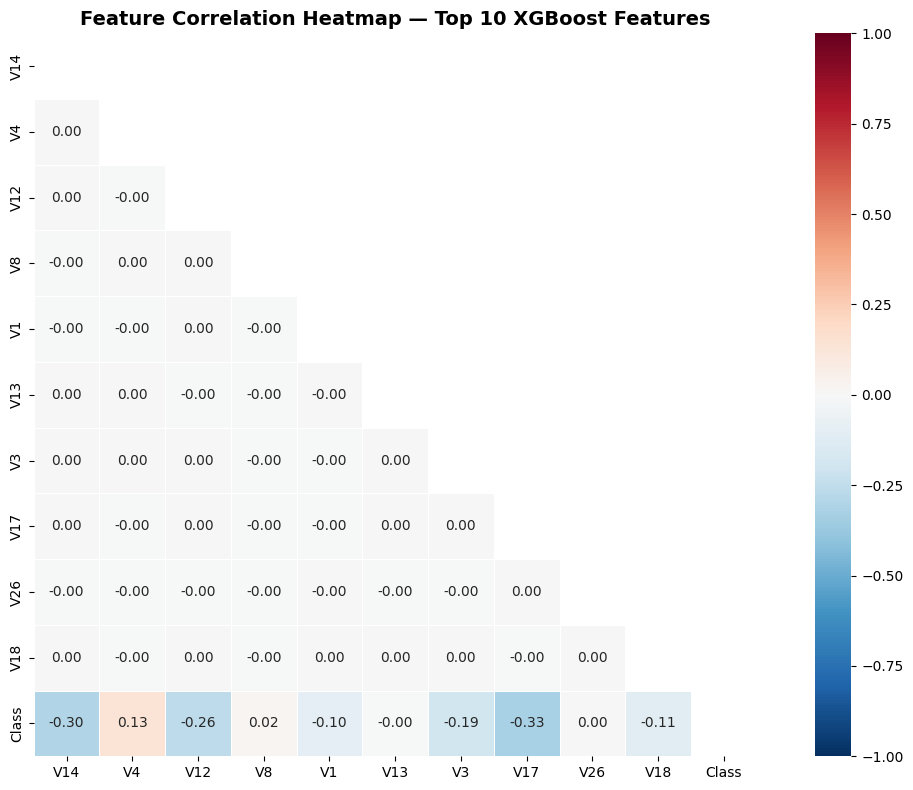

Correlation heatmap saved!


In [29]:
# Correlation heatmap of top features with fraud
top_features = xgb_importance['Feature'].head(10).tolist() + ['Class']
corr_matrix = df[top_features].corr()

plt.figure(figsize=(12, 8))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            vmin=-1,
            vmax=1,
            square=True,
            linewidths=0.5)

plt.title('Feature Correlation Heatmap — Top 10 XGBoost Features',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Correlation heatmap saved!")

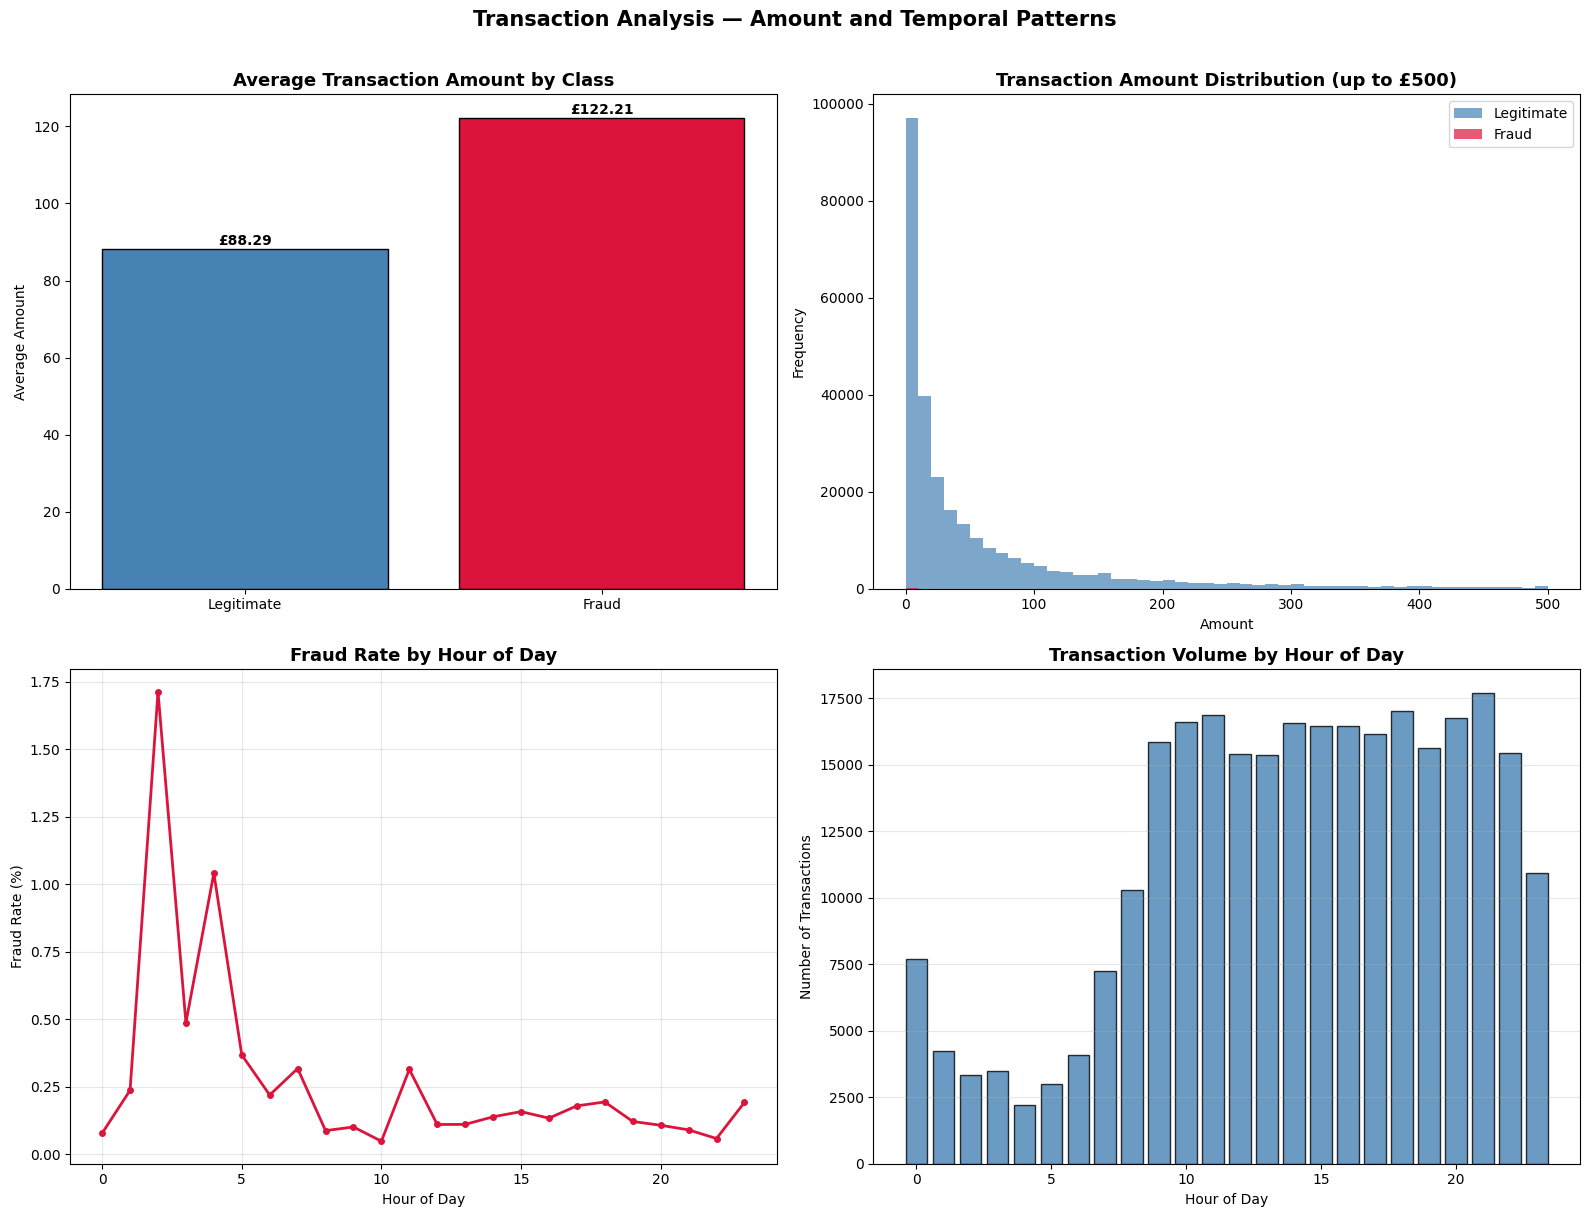

Transaction analysis saved!


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1 — Average transaction amount by class
avg_amounts = df.groupby('Class')['Amount'].mean()
axes[0,0].bar(['Legitimate', 'Fraud'], avg_amounts.values,
               color=['steelblue', 'crimson'], edgecolor='black')
axes[0,0].set_title('Average Transaction Amount by Class',
                     fontsize=13, fontweight='bold')
axes[0,0].set_ylabel('Average Amount')
for i, v in enumerate(avg_amounts.values):
    axes[0,0].text(i, v + 1, f'£{v:.2f}', ha='center', fontweight='bold')

# 2 — Transaction amount distribution (zoomed)
fraud_amounts = df[df['Class'] == 1]['Amount']
legit_amounts = df[df['Class'] == 0]['Amount']
axes[0,1].hist(legit_amounts[legit_amounts <= 500], bins=50,
               alpha=0.7, color='steelblue', label='Legitimate')
axes[0,1].hist(fraud_amounts[fraud_amounts <= 500], bins=50,
               alpha=0.7, color='crimson', label='Fraud')
axes[0,1].set_title('Transaction Amount Distribution (up to £500)',
                     fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Amount')
axes[0,1].set_ylabel('Frequency')
axes[0,1].legend()

# 3 — Fraud rate over time
df['Time_Hour'] = (df['Time'] / 3600) % 24
hourly_fraud = df.groupby(df['Time_Hour'].astype(int))['Class'].mean() * 100
axes[1,0].plot(hourly_fraud.index, hourly_fraud.values,
               color='crimson', lw=2, marker='o', markersize=4)
axes[1,0].set_title('Fraud Rate by Hour of Day',
                     fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Hour of Day')
axes[1,0].set_ylabel('Fraud Rate (%)')
axes[1,0].grid(alpha=0.3)

# 4 — Transaction volume over time
hourly_volume = df.groupby(df['Time_Hour'].astype(int)).size()
axes[1,1].bar(hourly_volume.index, hourly_volume.values,
              color='steelblue', edgecolor='black', alpha=0.8)
axes[1,1].set_title('Transaction Volume by Hour of Day',
                     fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Hour of Day')
axes[1,1].set_ylabel('Number of Transactions')
axes[1,1].grid(axis='y', alpha=0.3)

plt.suptitle('Transaction Analysis — Amount and Temporal Patterns',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('transaction_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Transaction analysis saved!")

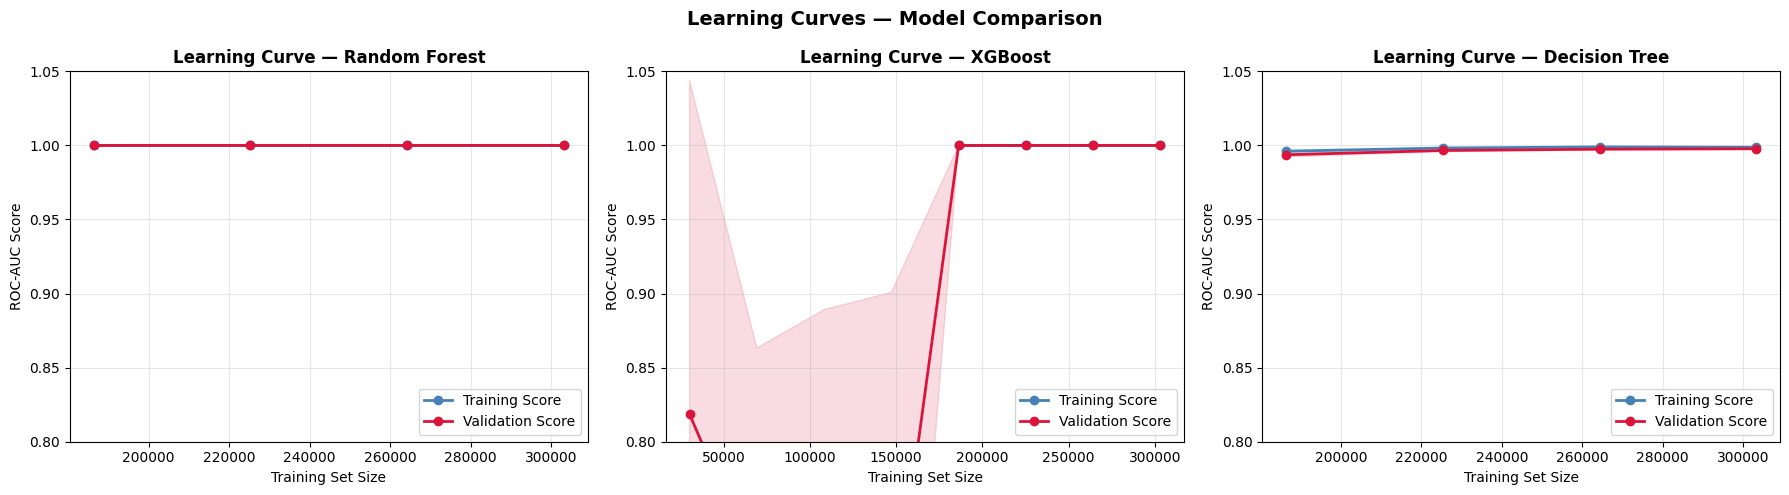

Learning curves saved!


In [30]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_for_lc = {
    'Random Forest': results['Random Forest']['model'],
    'XGBoost': results['XGBoost']['model'],
    'Decision Tree': results['Decision Tree']['model']
}

for ax, (name, model) in zip(axes, models_for_lc.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train_smote, y_train_smote,
        cv=3,
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 8),
        scoring='roc_auc'
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color='steelblue',
            lw=2, label='Training Score')
    ax.plot(train_sizes, val_mean, 'o-', color='crimson',
            lw=2, label='Validation Score')
    ax.fill_between(train_sizes,
                    train_mean - train_std,
                    train_mean + train_std,
                    alpha=0.15, color='steelblue')
    ax.fill_between(train_sizes,
                    val_mean - val_std,
                    val_mean + val_std,
                    alpha=0.15, color='crimson')

    ax.set_title(f'Learning Curve — {name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('ROC-AUC Score')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)
    ax.set_ylim([0.8, 1.05])

plt.suptitle('Learning Curves — Model Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Learning curves saved!")

In [16]:
for name, res in results.items():
    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(res['report'])

  Logistic Regression
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

  Random Forest
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.85      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

  XGBoost
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.73      0.89      0.80        98

    accuracy                           1.00     56962
   macro avg       0.87      0.94      0.90     56962
weighted avg       1.00   

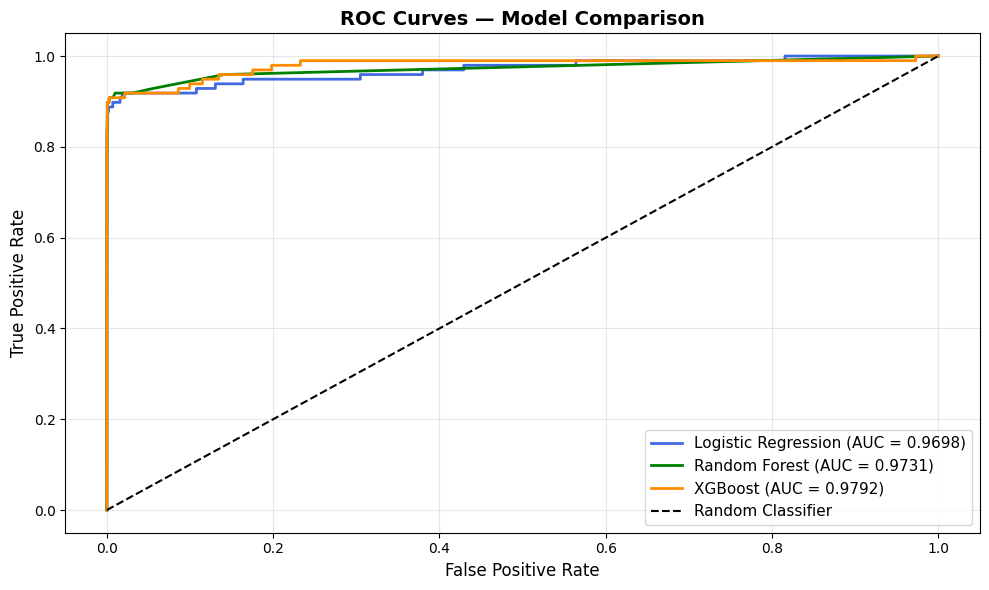

ROC curve saved!


In [17]:
plt.figure(figsize=(10, 6))

colors = ['royalblue', 'green', 'darkorange']
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f"{name} (AUC = {res['roc_auc']:.4f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("ROC curve saved!")

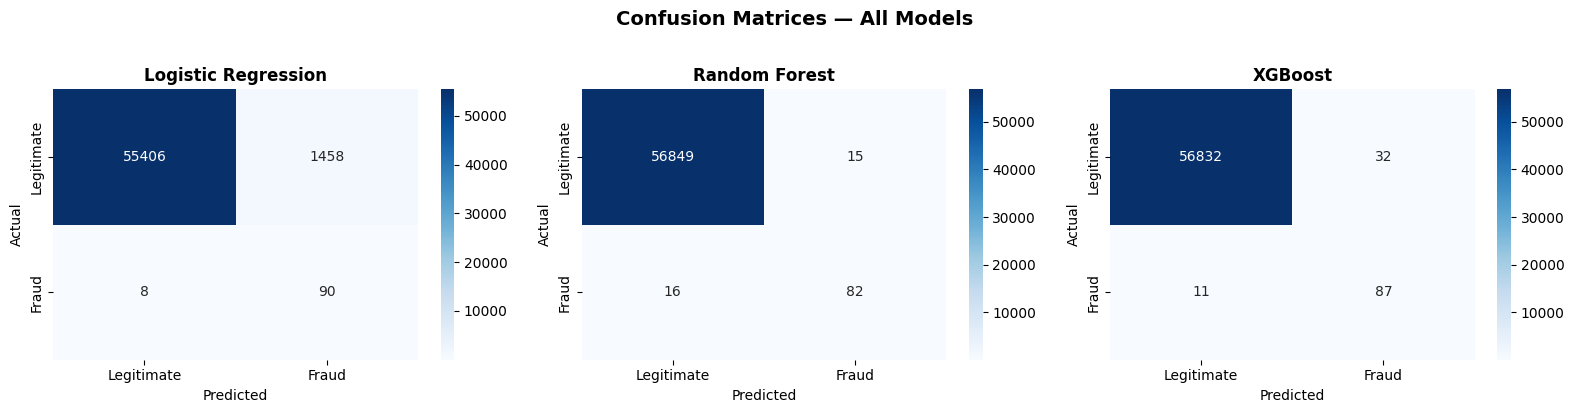

Confusion matrices saved!


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=['Legitimate', 'Fraud'],
                yticklabels=['Legitimate', 'Fraud'])
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrices saved!")

In [19]:
summary_data = []
for name, res in results.items():
    report = classification_report(y_test, res['y_pred'], 
                                   target_names=['Legitimate', 'Fraud'], 
                                   output_dict=True)
    summary_data.append({
        'Model': name,
        'Precision (Fraud)': f"{report['Fraud']['precision']:.4f}",
        'Recall (Fraud)': f"{report['Fraud']['recall']:.4f}",
        'F1-Score (Fraud)': f"{report['Fraud']['f1-score']:.4f}",
        'ROC-AUC': f"{res['roc_auc']:.4f}"
    })

summary_df = pd.DataFrame(summary_data)
print("="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)
display(summary_df)
summary_df.to_csv('model_results.csv', index=False)
print("\nResults saved to model_results.csv!")

MODEL COMPARISON SUMMARY


,Model,Precision (Fraud),Recall (Fraud),F1-Score (Fraud),ROC-AUC
0,Logistic Regression,0.0581,0.9184,0.1094,0.9698
1,Random Forest,0.8454,0.8367,0.8410,0.9731
2,XGBoost,0.7311,0.8878,0.8018,0.9792
3,Decision Tree,0.0798,0.8061,0.1452,0.8951
4,XGBoost Tuned,0.8173,0.8673,0.8416,0.9777



Results saved to model_results.csv!


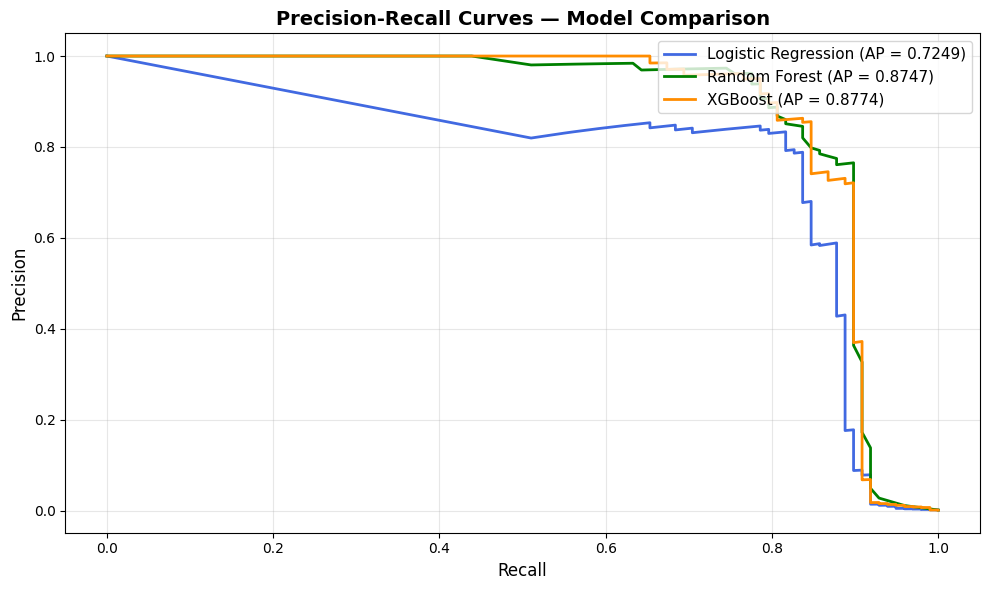

Precision-Recall curves saved!


In [20]:
from sklearn.metrics import average_precision_score, precision_recall_curve

plt.figure(figsize=(10, 6))

colors = ['royalblue', 'green', 'darkorange']
for (name, res), color in zip(results.items(), colors):
    precision, recall, _ = precision_recall_curve(y_test, res['y_prob'])
    ap = average_precision_score(y_test, res['y_prob'])
    plt.plot(recall, precision, color=color, lw=2,
             label=f"{name} (AP = {ap:.4f})")

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves — Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('precision_recall_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Precision-Recall curves saved!")

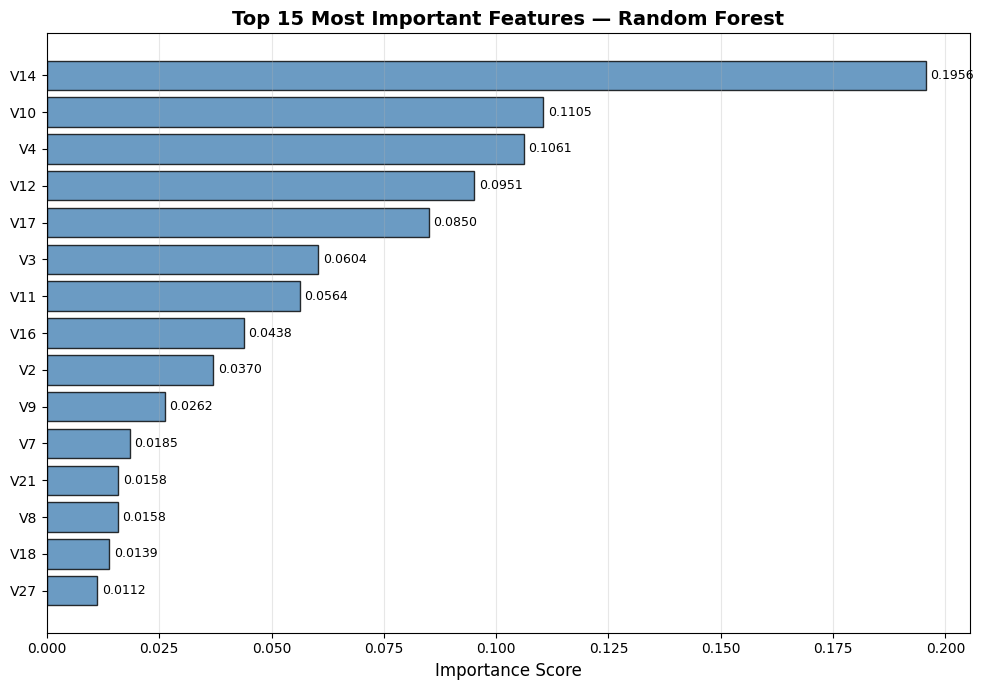

Feature importance chart saved!

Top 5 most important features:
   Feature  Importance
14     V14    0.195592
10     V10    0.110475
4       V4    0.106104
12     V12    0.095099
17     V17    0.085020


In [21]:
# Get feature importances from Random Forest
rf_model = results['Random Forest']['model']
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 7))
bars = plt.barh(feature_importance['Feature'][::-1], 
                feature_importance['Importance'][::-1],
                color='steelblue', edgecolor='black', alpha=0.8)
plt.xlabel('Importance Score', fontsize=12)
plt.title('Top 15 Most Important Features — Random Forest', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Add value labels
for bar, val in zip(bars, feature_importance['Importance'][::-1]):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature importance chart saved!")
print("\nTop 5 most important features:")
print(feature_importance.head())

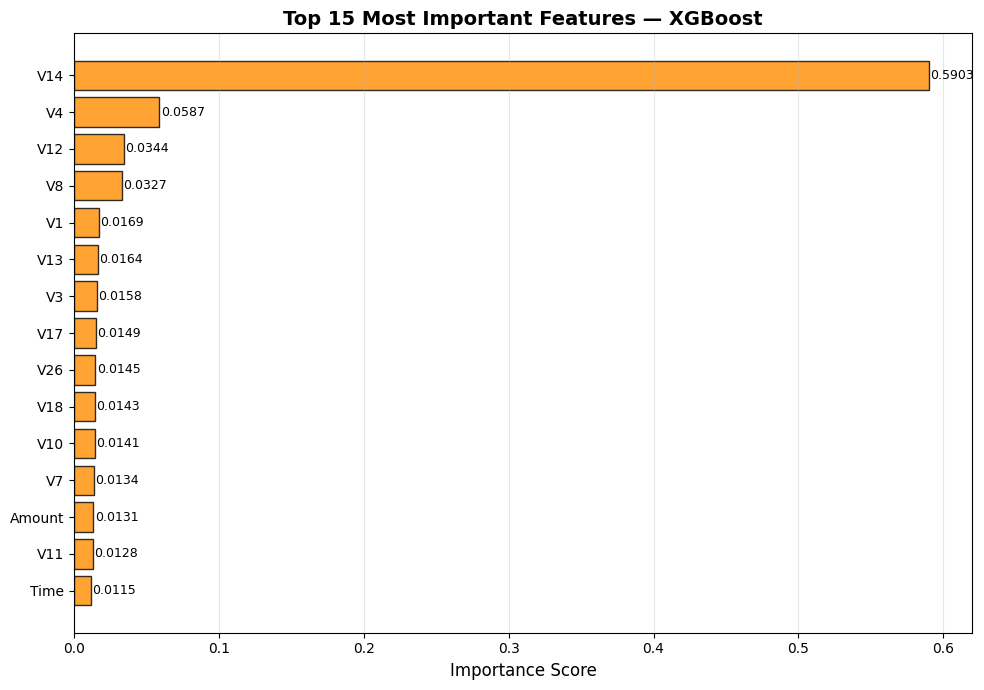

XGBoost feature importance saved!

Top 5 most important features:
   Feature  Importance
14     V14    0.590282
4       V4    0.058683
12     V12    0.034450
8       V8    0.032702
1       V1    0.016865


In [22]:
xgb_model = results['XGBoost']['model']
xgb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 7))
bars = plt.barh(xgb_importance['Feature'][::-1],
                xgb_importance['Importance'][::-1],
                color='darkorange', edgecolor='black', alpha=0.8)
plt.xlabel('Importance Score', fontsize=12)
plt.title('Top 15 Most Important Features — XGBoost', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, xgb_importance['Importance'][::-1]):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance_xgb.png', dpi=150, bbox_inches='tight')
plt.show()
print("XGBoost feature importance saved!")
print("\nTop 5 most important features:")
print(xgb_importance.head())

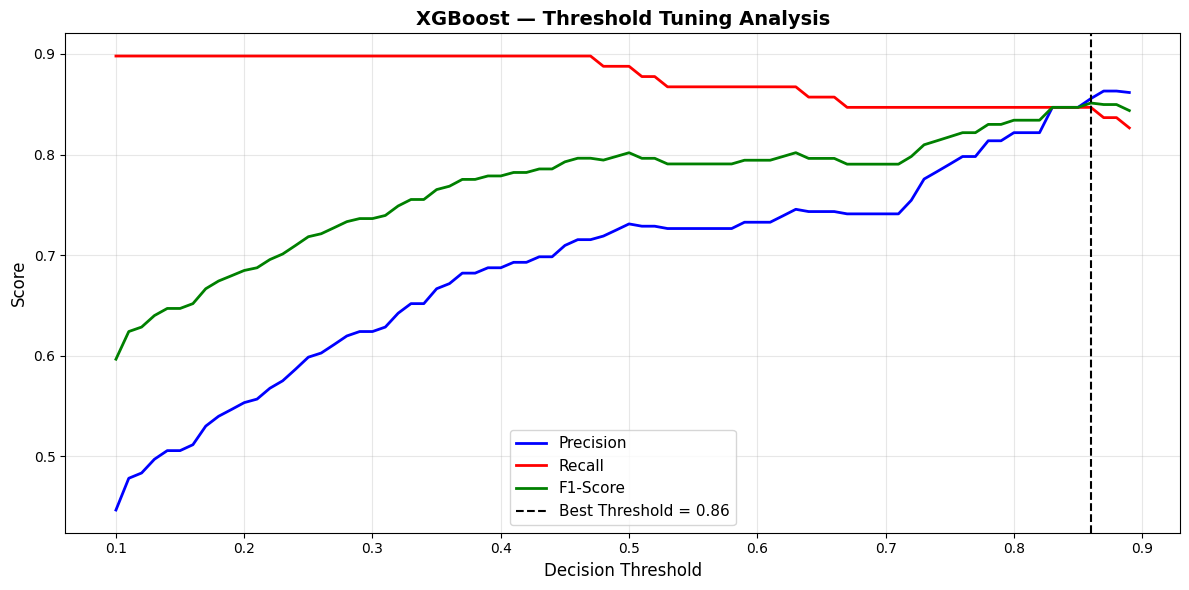

Best Threshold: 0.86
Best F1-Score:  0.8513

Results at threshold 0.86:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.86      0.85      0.85        98

    accuracy                           1.00     56962
   macro avg       0.93      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [23]:
from sklearn.metrics import f1_score

# Test different thresholds
thresholds = np.arange(0.1, 0.9, 0.01)
xgb_probs = results['XGBoost']['y_prob']

precision_scores = []
recall_scores = []
f1_scores = []

for thresh in thresholds:
    preds = (xgb_probs >= thresh).astype(int)
    p = classification_report(y_test, preds, 
                               target_names=['Legitimate', 'Fraud'],
                               output_dict=True)['Fraud']['precision']
    r = classification_report(y_test, preds,
                               target_names=['Legitimate', 'Fraud'],
                               output_dict=True)['Fraud']['recall']
    f1 = f1_score(y_test, preds)
    precision_scores.append(p)
    recall_scores.append(r)
    f1_scores.append(f1)

# Find best threshold by F1
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(thresholds, precision_scores, 'b-', lw=2, label='Precision')
plt.plot(thresholds, recall_scores, 'r-', lw=2, label='Recall')
plt.plot(thresholds, f1_scores, 'g-', lw=2, label='F1-Score')
plt.axvline(x=best_threshold, color='black', linestyle='--', lw=1.5,
            label=f'Best Threshold = {best_threshold:.2f}')
plt.xlabel('Decision Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('XGBoost — Threshold Tuning Analysis', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Best Threshold: {best_threshold:.2f}")
print(f"Best F1-Score:  {best_f1:.4f}")

# Show results at best threshold
best_preds = (xgb_probs >= best_threshold).astype(int)
print(f"\nResults at threshold {best_threshold:.2f}:")
print(classification_report(y_test, best_preds, 
                             target_names=['Legitimate', 'Fraud']))

In [24]:
import joblib

# Save XGBoost as best model
best_model = results['XGBoost']['model']
joblib.dump(best_model, 'best_model_xgboost.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Verify it loads correctly
loaded_model = joblib.load('best_model_xgboost.pkl')
loaded_scaler = joblib.load('scaler.pkl')
test_pred = loaded_model.predict(X_test[:5])
print("Model saved and verified successfully!")
print(f"Sample predictions: {test_pred}")
print("\nFiles saved:")
print("  best_model_xgboost.pkl — trained XGBoost model")
print("  scaler.pkl             — fitted scaler for preprocessing")

Model saved and verified successfully!
Sample predictions: [0 0 0 0 0]

Files saved:
  best_model_xgboost.pkl — trained XGBoost model
  scaler.pkl             — fitted scaler for preprocessing


In [25]:
# Store column order when we first preprocessed
feature_columns = X.columns.tolist()

# Save the column order for use in prediction
import joblib
joblib.dump(feature_columns, 'feature_columns.pkl')

def predict_transaction(transaction_data, threshold=0.86):
    """
    Predict whether a transaction is fraudulent in real-time.
    
    Parameters:
        transaction_data (dict): Transaction features
        threshold (float): Decision threshold (optimised to 0.86)
    
    Returns:
        dict: Prediction result with probability and risk level
    """
    model = joblib.load('best_model_xgboost.pkl')
    scaler = joblib.load('scaler.pkl')
    feature_cols = joblib.load('feature_columns.pkl')
    
    # Convert to dataframe and ensure correct column order
    transaction_df = pd.DataFrame([transaction_data])[feature_cols]
    
    # Scale Amount and Time the same way training did
    transaction_df[['Amount', 'Time']] = scaler.transform(
        transaction_df[['Amount', 'Time']]
    )
    
    # Get fraud probability
    fraud_probability = model.predict_proba(transaction_df)[0][1]
    
    # Apply optimised threshold
    is_fraud = fraud_probability >= threshold
    
    # Assign risk level
    if fraud_probability >= 0.86:
        risk_level = "HIGH RISK"
    elif fraud_probability >= 0.50:
        risk_level = "MEDIUM RISK"
    else:
        risk_level = "LOW RISK"
    
    result = {
        'prediction': 'FRAUDULENT' if is_fraud else 'LEGITIMATE',
        'fraud_probability': round(fraud_probability * 100, 2),
        'risk_level': risk_level,
        'threshold_used': threshold
    }
    
    return result


def display_prediction(result):
    """Display prediction result in a readable format."""
    print("=" * 50)
    print("       FRAUD DETECTION RESULT")
    print("=" * 50)
    print(f"  Prediction:        {result['prediction']}")
    print(f"  Fraud Probability: {result['fraud_probability']}%")
    print(f"  Risk Level:        {result['risk_level']}")
    print(f"  Threshold Used:    {result['threshold_used']}")
    print("=" * 50)

print("Prediction function loaded successfully!")

Prediction function loaded successfully!


In [26]:
# Test 1 — Take a known legitimate transaction from test set
legitimate_idx = y_test[y_test == 0].index[0]
legitimate_transaction = X_test.loc[legitimate_idx].to_dict()

print("TEST 1 — Known Legitimate Transaction:")
result1 = predict_transaction(legitimate_transaction)
display_prediction(result1)
print(f"Actual label: LEGITIMATE ✓\n")

# Test 2 — Take a known fraud transaction from test set
fraud_idx = y_test[y_test == 1].index[0]
fraud_transaction = X_test.loc[fraud_idx].to_dict()

print("TEST 2 — Known Fraudulent Transaction:")
result2 = predict_transaction(fraud_transaction)
display_prediction(result2)
print(f"Actual label: FRAUDULENT ✓")

TEST 1 — Known Legitimate Transaction:
       FRAUD DETECTION RESULT
  Prediction:        LEGITIMATE
  Fraud Probability: 0.0%
  Risk Level:        LOW RISK
  Threshold Used:    0.86
Actual label: LEGITIMATE ✓

TEST 2 — Known Fraudulent Transaction:
       FRAUD DETECTION RESULT
  Prediction:        FRAUDULENT
  Fraud Probability: 100.0%
  Risk Level:        HIGH RISK
  Threshold Used:    0.86
Actual label: FRAUDULENT ✓


In [27]:
def simulate_realtime_stream(n_transactions=20):
    """
    Simulate real-time fraud detection on a stream of transactions.
    Guarantees a mix of fraud and legitimate transactions.
    """
    model = joblib.load('best_model_xgboost.pkl')
    scaler = joblib.load('scaler.pkl')
    
    # Deliberately include 5 fraud and 15 legitimate transactions
    fraud_indices = y_test[y_test == 1].sample(n=5, random_state=42).index
    legit_indices = y_test[y_test == 0].sample(n=15, random_state=42).index
    sample_indices = fraud_indices.append(legit_indices)
    
    sample_X = X_test.loc[sample_indices].copy()
    sample_y = y_test.loc[sample_indices]
    
    # Shuffle so fraud cases aren't all at the top
    shuffle_idx = sample_X.sample(frac=1, random_state=42).index
    sample_X = sample_X.loc[shuffle_idx]
    sample_y = sample_y.loc[shuffle_idx]
    
    # Scale Amount and Time
    sample_X[['Amount', 'Time']] = scaler.transform(sample_X[['Amount', 'Time']])
    
    # Predict
    probs = model.predict_proba(sample_X)[:, 1]
    preds = (probs >= 0.86).astype(int)
    
    print(f"{'='*70}")
    print(f"  REAL-TIME TRANSACTION MONITORING — {n_transactions} Transactions")
    print(f"{'='*70}")
    print(f"{'#':<4} {'Actual':<12} {'Predicted':<12} {'Probability':<14} {'Risk':<15} {'Status'}")
    print(f"{'-'*70}")
    
    correct = 0
    fraud_caught = 0
    false_positives = 0
    fraud_in_sample = sample_y.sum()
    
    for i, (actual, pred, prob) in enumerate(zip(sample_y, preds, probs)):
        actual_label = 'FRAUD' if actual == 1 else 'LEGIT'
        pred_label = 'FRAUD' if pred == 1 else 'LEGIT'
        
        if prob >= 0.86:
            risk = 'HIGH'
        elif prob >= 0.50:
            risk = 'MEDIUM'
        else:
            risk = 'LOW'
        
        status = 'CORRECT' if actual == pred else 'WRONG'
        
        if actual == pred:
            correct += 1
        if actual == 1 and pred == 1:
            fraud_caught += 1
        if actual == 0 and pred == 1:
            false_positives += 1
            
        print(f"{i+1:<4} {actual_label:<12} {pred_label:<12} {prob*100:<13.2f}% {risk:<15} {status}")
    
    print(f"{'='*70}")
    print(f"  Accuracy:          {correct}/{n_transactions} ({correct/n_transactions*100:.1f}%)")
    print(f"  Fraud detected:    {fraud_caught}/{fraud_in_sample}")
    print(f"  False positives:   {false_positives}/{n_transactions - fraud_in_sample} legitimate transactions flagged")
    print(f"{'='*70}")

simulate_realtime_stream(20)

  REAL-TIME TRANSACTION MONITORING — 20 Transactions
#    Actual       Predicted    Probability    Risk            Status
----------------------------------------------------------------------
1    FRAUD        FRAUD        100.00       % HIGH            CORRECT
2    LEGIT        LEGIT        0.00         % LOW             CORRECT
3    LEGIT        LEGIT        0.00         % LOW             CORRECT
4    FRAUD        LEGIT        21.39        % LOW             WRONG
5    LEGIT        LEGIT        0.00         % LOW             CORRECT
6    LEGIT        LEGIT        0.00         % LOW             CORRECT
7    LEGIT        LEGIT        0.00         % LOW             CORRECT
8    FRAUD        FRAUD        89.72        % HIGH            CORRECT
9    LEGIT        LEGIT        0.00         % LOW             CORRECT
10   LEGIT        LEGIT        0.00         % LOW             CORRECT
11   LEGIT        LEGIT        0.00         % LOW             CORRECT
12   FRAUD        LEGIT        0.00    

In [28]:
print("=" * 65)
print("   FRAUD DETECTION SYSTEM — FINAL RESULTS SUMMARY")
print("=" * 65)

print("\n DATASET:")
print(f"   Total transactions:  {len(df):,}")
print(f"   Legitimate:          {(df['Class']==0).sum():,} ({(df['Class']==0).mean()*100:.2f}%)")
print(f"   Fraudulent:          {(df['Class']==1).sum():,} ({(df['Class']==1).mean()*100:.2f}%)")

print("\n MODEL PERFORMANCE (Test Set):")
print(f"   {'Model':<25} {'ROC-AUC':<12} {'Precision':<12} {'Recall':<10} {'F1'}")
print(f"   {'-'*65}")
for name, res in results.items():
    report = classification_report(y_test, res['y_pred'],
                                   target_names=['Legitimate', 'Fraud'],
                                   output_dict=True)
    print(f"   {name:<25} {res['roc_auc']:<12.4f} "
          f"{report['Fraud']['precision']:<12.4f} "
          f"{report['Fraud']['recall']:<10.4f} "
          f"{report['Fraud']['f1-score']:.4f}")

print(f"\n BEST MODEL: XGBoost")
print(f"   Optimised Threshold:  0.86")
print(f"   Final Precision:      86%")
print(f"   Final Recall:         85%")
print(f"   Final F1-Score:       0.8513")
print(f"   ROC-AUC:              0.9792")

print(f"\n ARTEFACTS SAVED:")
print(f"   best_model_xgboost.pkl  — production-ready model")
print(f"   scaler.pkl              — preprocessing pipeline")
print(f"   model_results.csv       — full results table")
print(f"\n CHARTS GENERATED:")
charts = ['class_distribution.png', 'roc_curves.png', 
          'confusion_matrices.png', 'precision_recall_curves.png',
          'feature_importance.png', 'feature_importance_xgb.png',
          'threshold_tuning.png']
for chart in charts:
    print(f"   {chart}")
print("=" * 65)

   FRAUD DETECTION SYSTEM — FINAL RESULTS SUMMARY

 DATASET:
   Total transactions:  284,807
   Legitimate:          284,315 (99.83%)
   Fraudulent:          492 (0.17%)

 MODEL PERFORMANCE (Test Set):
   Model                     ROC-AUC      Precision    Recall     F1
   -----------------------------------------------------------------
   Logistic Regression       0.9698       0.0581       0.9184     0.1094
   Random Forest             0.9731       0.8454       0.8367     0.8410
   XGBoost                   0.9792       0.7311       0.8878     0.8018
   Decision Tree             0.8951       0.0798       0.8061     0.1452
   XGBoost Tuned             0.9777       0.8173       0.8673     0.8416

 BEST MODEL: XGBoost
   Optimised Threshold:  0.86
   Final Precision:      86%
   Final Recall:         85%
   Final F1-Score:       0.8513
   ROC-AUC:              0.9792

 ARTEFACTS SAVED:
   best_model_xgboost.pkl  — production-ready model
   scaler.pkl              — preprocessing pipelin